# FrozenLake Game - Visualização com Matplotlib

Este notebook demonstra o ambiente FrozenLake, onde um agente deve navegar de um ponto de partida (0,0) até o objetivo (3,3), evitando buracos (células azuis).

**Legenda:**
- ⬜ Branco: Caminho livre
- 🟦 Azul: Buraco
- 🟩 Verde: Objetivo
- 🔴 Vermelho: Agente

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import clear_output
import pandas as pd

## 1. Definindo o Ambiente FrozenLake

Criamos um mapa 4x4 onde:
- `0` = Caminho livre
- `1` = Buraco (meleca/obstáculo)
- `2` = Objetivo

In [30]:
# Definindo o tamanho do ambiente (tabuleiro 2D)
n_rows, n_cols = 4, 4

# Criando o mapa FrozenLake (0 para caminhos livres, 1 para buracos, 2 para o objetivo)
frozen_lake_map = np.array([
    [0, 0, 0, 0],
    [0, 1, 0, 1],
    [0, 0, 0, 0],
    [0, 1, 0, 2]
])

print("Mapa do FrozenLake:")
print(frozen_lake_map)
print("\nLegenda: 0=Livre, 1=Buraco, 2=Objetivo")

Mapa do FrozenLake:
[[0 0 0 0]
 [0 1 0 1]
 [0 0 0 0]
 [0 1 0 2]]

Legenda: 0=Livre, 1=Buraco, 2=Objetivo


## 2. Função para Desenhar o Tabuleiro

Renderizamos o ambiente usando matplotlib para visualização no Colab.

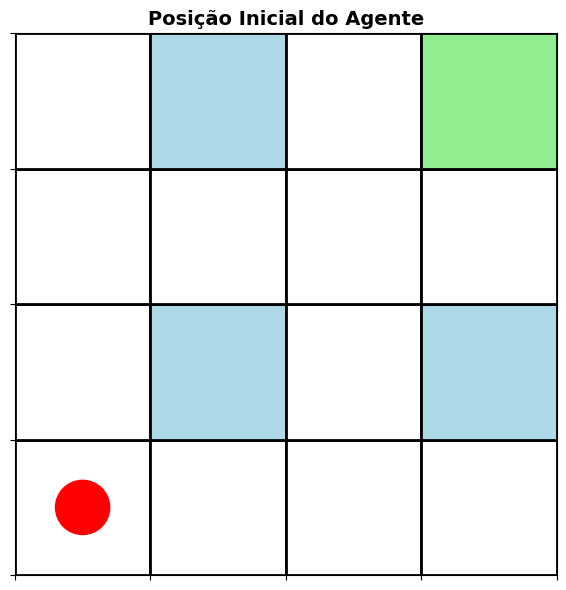

In [31]:
# Função para desenhar o tabuleiro do FrozenLake com matplotlib
def draw_frozen_lake(agent_position, title="FrozenLake Game", show_path=None):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))

    # Desenha o mapa
    for row in range(n_rows):
        for col in range(n_cols):
            if frozen_lake_map[row, col] == 0:
                color = 'white'
            elif frozen_lake_map[row, col] == 1:
                color = 'lightblue'
            elif frozen_lake_map[row, col] == 2:
                color = 'lightgreen'

            rect = patches.Rectangle((col, n_rows - 1 - row), 1, 1,
                                     linewidth=2, edgecolor='black',
                                     facecolor=color)
            ax.add_patch(rect)

    # Desenha o caminho percorrido (opcional)
    if show_path is not None:
        for i in range(len(show_path) - 1):
            x1 = show_path[i][1] + 0.5
            y1 = n_rows - 1 - show_path[i][0] + 0.5
            x2 = show_path[i+1][1] + 0.5
            y2 = n_rows - 1 - show_path[i+1][0] + 0.5
            ax.plot([x1, x2], [y1, y2], 'b-', alpha=0.3, linewidth=2)

    # Desenha o agente (círculo vermelho)
    agent_x = agent_position[1] + 0.5
    agent_y = n_rows - 1 - agent_position[0] + 0.5
    circle = patches.Circle((agent_x, agent_y), 0.2, color='red', zorder=5)
    ax.add_patch(circle)

    # Configurar o eixo
    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, n_rows)
    ax.set_aspect('equal')
    ax.set_xticks(range(n_cols + 1))
    ax.set_yticks(range(n_rows + 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.invert_yaxis()

    # Adicionar grid
    ax.grid(True, which='both', color='black', linewidth=0.5)

    plt.tight_layout()
    return fig

# Testando a função com posição inicial
agent_position = [0, 0]
draw_frozen_lake(agent_position, "Posição Inicial do Agente")
plt.show()

## 3. Função para Movimentar o Agente

Define como o agente se move no ambiente.

In [32]:
# Função para movimentar o agente com base na ação
def move_agent(current_position, action):
    """
    Move o agente em uma direção específica.

    Args:
        current_position: Lista [row, col] com posição atual
        action: String indicando a direção ('up', 'down', 'left', 'right')
    """
    if action == 'down' and current_position[0] < n_rows - 1:
        current_position[0] += 1
    elif action == 'up' and current_position[0] > 0:
        current_position[0] -= 1
    elif action == 'left' and current_position[1] > 0:
        current_position[1] -= 1
    elif action == 'right' and current_position[1] < n_cols - 1:
        current_position[1] += 1

print("Função de movimento definida!")

Função de movimento definida!


## 4. Executando a Simulação com Rastreamento de Todos os Passos

O agente faz movimentos aleatórios e rastreamos cada etapa.

In [33]:
# Número de passos que o agente dará
num_steps = 20

# Posição inicial do agente
agent_position = [0, 0]

# Listas para rastrear todos os passos
positions_history = [agent_position.copy()]  # Posições visitadas
actions_history = []                          # Ações tomadas
step_counter = 0                              # Contador de passos

print("\n" + "="*70)
print("INICIANDO SIMULAÇÃO DO FROZENLAKE")
print("="*70 + "\n")

# Simulação do jogo
for step in range(num_steps):
    # Escolhe uma ação aleatória
    action = np.random.choice(['up', 'down', 'left', 'right'])
    actions_history.append(action)

    # Posição antes do movimento
    previous_position = agent_position.copy()

    # Move o agente
    move_agent(agent_position, action)

    # Adiciona a nova posição ao histórico
    positions_history.append(agent_position.copy())
    step_counter += 1

    # Verifica o tipo de célula
    cell_type = frozen_lake_map[agent_position[0], agent_position[1]]

    if cell_type == 1:
        print(f"❌ Passo {step_counter}: {previous_position} → {agent_position} (ação: {action.upper()}) = BURACO!")
        agent_position = [0, 0]
        positions_history = [[0, 0]]

    elif cell_type == 2:
        print(f"🎉 Passo {step_counter}: {previous_position} → {agent_position} (ação: {action.upper()}) = OBJETIVO!")
        agent_position = [0, 0]
        positions_history = [[0, 0]]
    else:
        print(f"✓  Passo {step_counter}: {previous_position} → {agent_position} (ação: {action.upper()})")

print(f"\n✓ Simulação concluída!")
print(f"Total de passos realizados: {step_counter}")
print(f"Total de posições visitadas: {len(positions_history)}")


INICIANDO SIMULAÇÃO DO FROZENLAKE

✓  Passo 1: [0, 0] → [0, 0] (ação: LEFT)
✓  Passo 2: [0, 0] → [1, 0] (ação: DOWN)
✓  Passo 3: [1, 0] → [1, 0] (ação: LEFT)
✓  Passo 4: [1, 0] → [2, 0] (ação: DOWN)
✓  Passo 5: [2, 0] → [2, 0] (ação: LEFT)
✓  Passo 6: [2, 0] → [3, 0] (ação: DOWN)
✓  Passo 7: [3, 0] → [3, 0] (ação: DOWN)
✓  Passo 8: [3, 0] → [3, 0] (ação: LEFT)
✓  Passo 9: [3, 0] → [3, 0] (ação: LEFT)
✓  Passo 10: [3, 0] → [2, 0] (ação: UP)
✓  Passo 11: [2, 0] → [2, 0] (ação: LEFT)
✓  Passo 12: [2, 0] → [2, 0] (ação: LEFT)
✓  Passo 13: [2, 0] → [2, 0] (ação: LEFT)
✓  Passo 14: [2, 0] → [2, 0] (ação: LEFT)
✓  Passo 15: [2, 0] → [2, 1] (ação: RIGHT)
❌ Passo 16: [2, 1] → [3, 1] (ação: DOWN) = BURACO!
✓  Passo 17: [0, 0] → [0, 0] (ação: UP)
✓  Passo 18: [0, 0] → [0, 1] (ação: RIGHT)
❌ Passo 19: [0, 1] → [1, 1] (ação: DOWN) = BURACO!
✓  Passo 20: [0, 0] → [0, 0] (ação: LEFT)

✓ Simulação concluída!
Total de passos realizados: 20
Total de posições visitadas: 2


## 5. Visualização Gráfica de Cada Passo

Mostra uma grade com vários momentos da simulação.

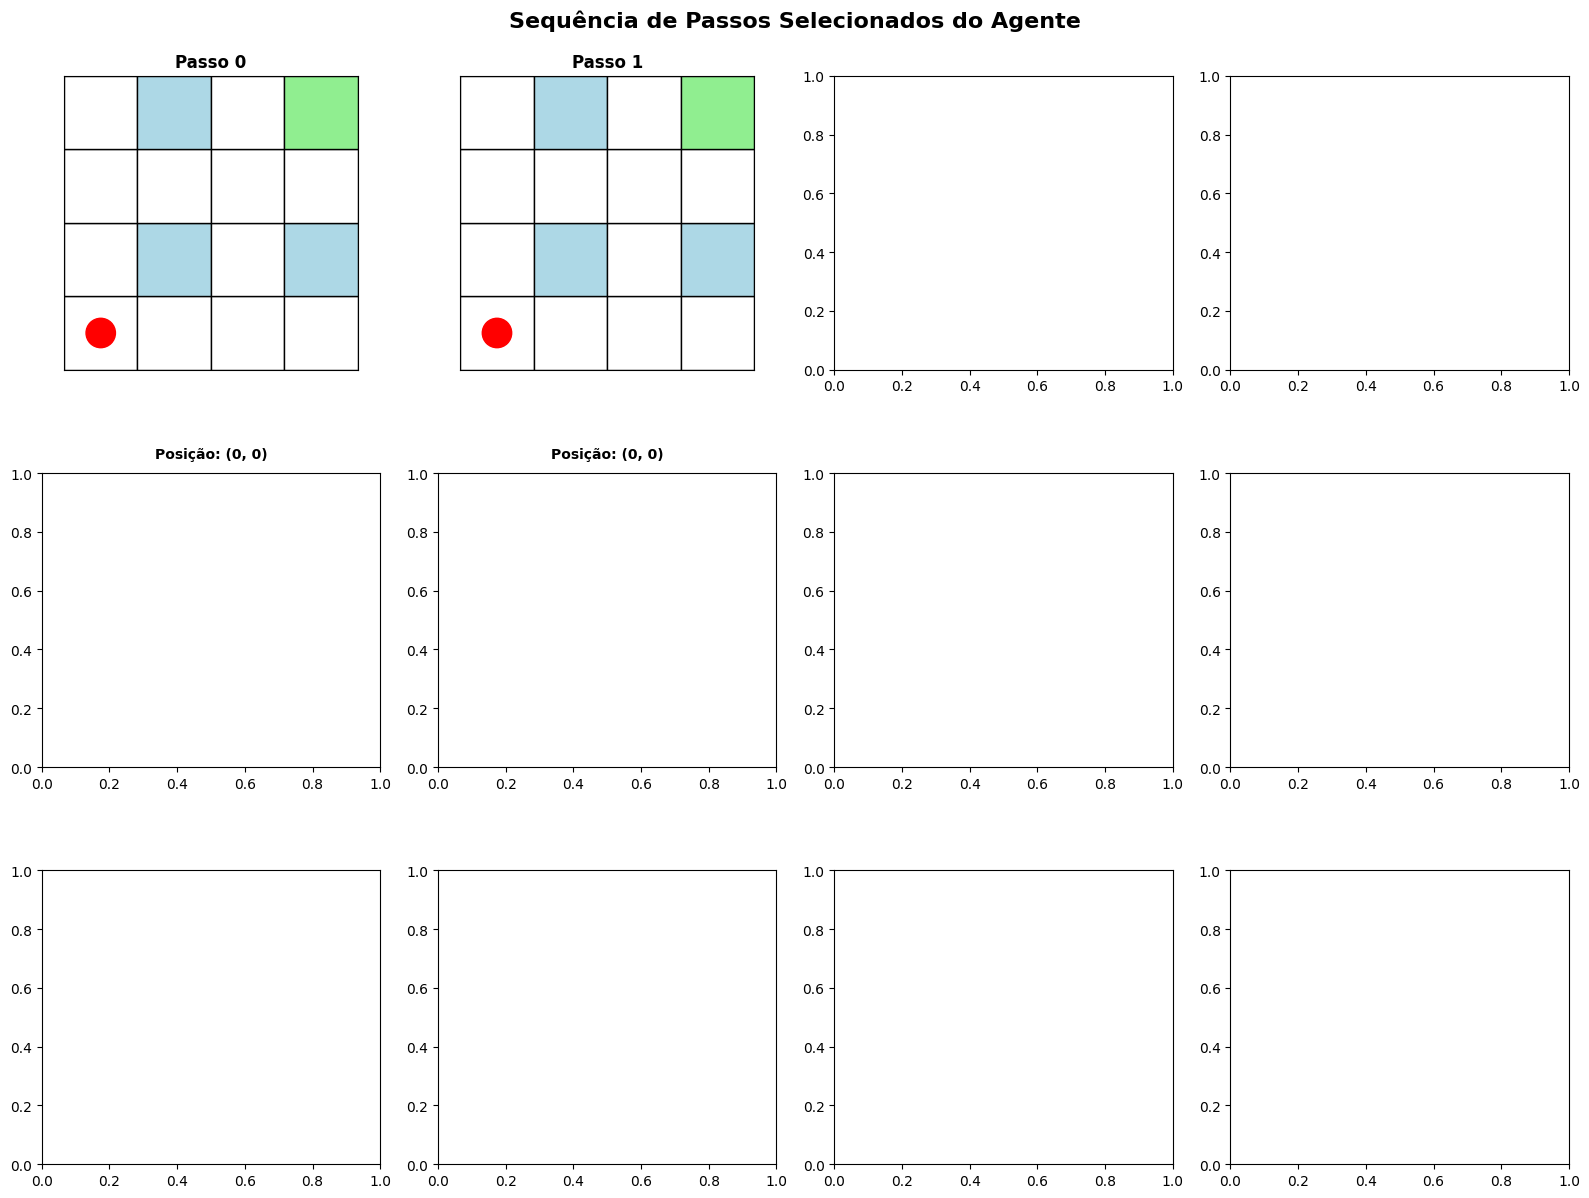

In [34]:
# Mostrar alguns passos selecionados em uma grade
steps_to_show = min(12, len(positions_history))  # Mostrar até 12 passos

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

# Distribuir os passos uniformemente ao longo da simulação
indices = np.linspace(0, len(positions_history) - 1, steps_to_show, dtype=int)

for idx, step_idx in enumerate(indices):
    ax = axes[idx]
    pos = positions_history[step_idx]

    # Desenha o mapa completo
    for row in range(n_rows):
        for col in range(n_cols):
            if frozen_lake_map[row, col] == 0:
                color = 'white'
            elif frozen_lake_map[row, col] == 1:
                color = 'lightblue'
            elif frozen_lake_map[row, col] == 2:
                color = 'lightgreen'

            rect = patches.Rectangle((col, n_rows - 1 - row), 1, 1,
                                     linewidth=1, edgecolor='black',
                                     facecolor=color)
            ax.add_patch(rect)

    # Desenha o agente
    agent_x = pos[1] + 0.5
    agent_y = n_rows - 1 - pos[0] + 0.5
    circle = patches.Circle((agent_x, agent_y), 0.2, color='red', zorder=5)
    ax.add_patch(circle)

    # Adiciona texto com posição
    ax.text(0.5, -0.3, f'Posição: ({pos[0]}, {pos[1]})',
           transform=ax.transAxes, ha='center', fontsize=10, fontweight='bold')

    # Configurar o eixo
    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, n_rows)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Passo {step_idx}", fontweight='bold', fontsize=12)
    ax.invert_yaxis()
    ax.grid(True, which='both', color='gray', linewidth=0.5, alpha=0.3)

plt.suptitle('Sequência de Passos Selecionados do Agente', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 6. Visualização do Caminho Completo

Mostra o caminho total percorrido pelo agente em um único gráfico com numeração.

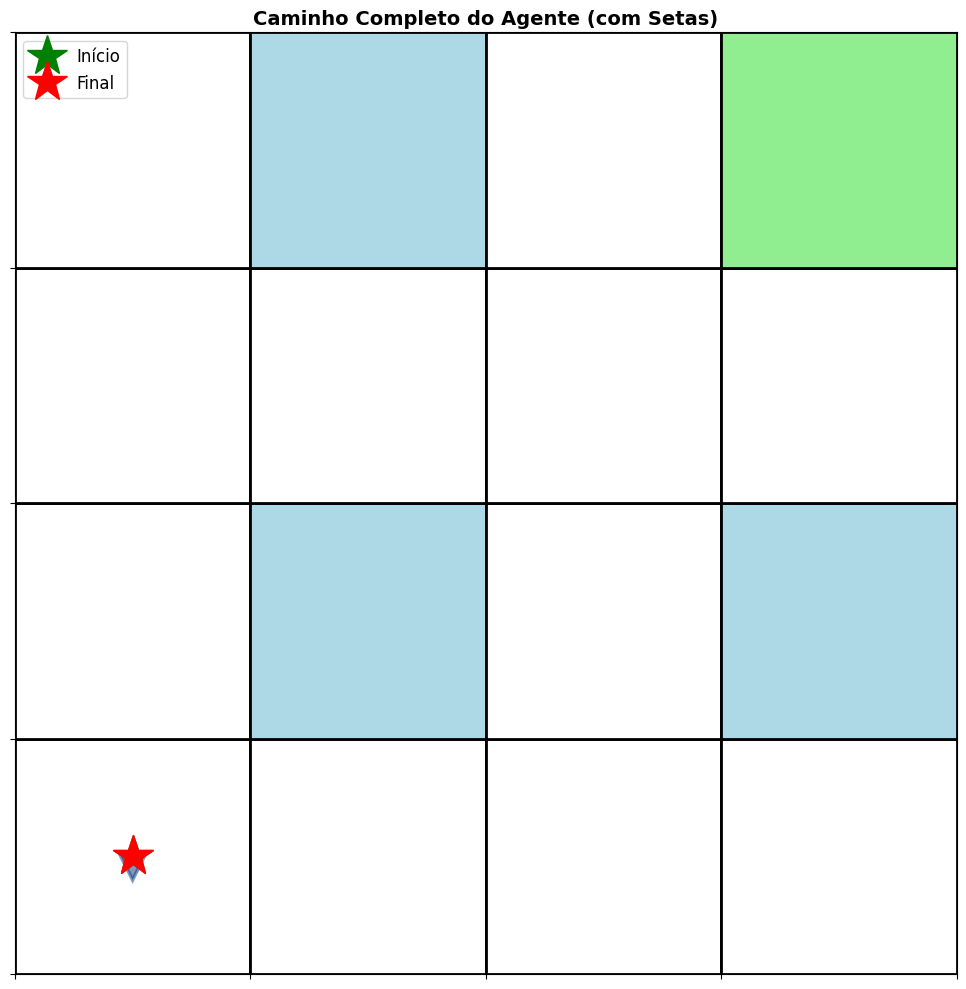

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Desenha o mapa
for row in range(n_rows):
    for col in range(n_cols):
        if frozen_lake_map[row, col] == 0:
            color = 'white'
        elif frozen_lake_map[row, col] == 1:
            color = 'lightblue'
        elif frozen_lake_map[row, col] == 2:
            color = 'lightgreen'

        rect = patches.Rectangle((col, n_rows - 1 - row), 1, 1,
                                 linewidth=2, edgecolor='black',
                                 facecolor=color)
        ax.add_patch(rect)

# Desenha o caminho percorrido com cores gradientes
for i in range(len(positions_history) - 1):
    x1 = positions_history[i][1] + 0.5
    y1 = n_rows - 1 - positions_history[i][0] + 0.5
    x2 = positions_history[i+1][1] + 0.5
    y2 = n_rows - 1 - positions_history[i+1][0] + 0.5

    # Cor muda a cada passo (mais escuro conforme progride)
    alpha = (i + 1) / max(len(positions_history), 2)
    ax.arrow(x1, y1, x2-x1, y2-y1, head_width=0.1, head_length=0.1,
            fc=(0, 0.2, 0.5), ec=(0, 0.2, 0.5), alpha=alpha, linewidth=2.5)

# Marca a posição inicial
ax.plot(0.5, n_rows - 0.5, 'g*', markersize=30, label='Início', zorder=10)

# Marca a posição final
final_pos = positions_history[-1]
final_x = final_pos[1] + 0.5
final_y = n_rows - 1 - final_pos[0] + 0.5
ax.plot(final_x, final_y, 'r*', markersize=30, label='Final', zorder=10)

# Configurar o eixo
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.set_aspect('equal')
ax.set_xticks(range(n_cols + 1))
ax.set_yticks(range(n_rows + 1))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_title('Caminho Completo do Agente (com Setas)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, which='both', color='black', linewidth=0.5)
ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

## 7. Tabela de Todos os Passos

Visualiza cada passo em formato de tabela.

In [36]:
# Criar DataFrame com todos os dados dos passos
data_steps = []

for i, pos in enumerate(positions_history):
    if i < len(actions_history):
        action = actions_history[i].upper()
    else:
        action = '-'

    cell_type = frozen_lake_map[pos[0], pos[1]]

    if cell_type == 0:
        cell_status = 'Caminho Livre'
    elif cell_type == 1:
        cell_status = '⚠️ BURACO'
    elif cell_type == 2:
        cell_status = '✓ OBJETIVO'

    data_steps.append({
        'Passo': i,
        'Linha': pos[0],
        'Coluna': pos[1],
        'Posição': f'({pos[0]}, {pos[1]})',
        'Ação': action,
        'Tipo de Célula': cell_status
    })

df_steps = pd.DataFrame(data_steps)

print("\n" + "="*80)
print("TABELA COMPLETA DE TODOS OS PASSOS REALIZADOS")
print("="*80 + "\n")
print(df_steps.to_string(index=False))


TABELA COMPLETA DE TODOS OS PASSOS REALIZADOS

 Passo  Linha  Coluna Posição Ação Tipo de Célula
     0      0       0  (0, 0) LEFT  Caminho Livre
     1      0       0  (0, 0) DOWN  Caminho Livre


## 8. Estatísticas Detalhadas da Simulação

Análise completa do comportamento do agente.

In [37]:
# Contar ações
actions_count = {}
for action in actions_history:
    actions_count[action] = actions_count.get(action, 0) + 1

# Posições únicas visitadas
unique_positions = len(set(map(tuple, positions_history)))

print("ESTATÍSTICAS DETALHADAS DA SIMULAÇÃO")

print(f"\nInformações Gerais:")
print(f"   • Total de passos planejados: {num_steps}")
print(f"   • Total de passos realizados: {len(actions_history)}")
print(f"   • Total de posições no histórico: {len(positions_history)}")
print(f"   • Posições ÚNICAS visitadas: {unique_positions}")
print(f"   • Posição final: {positions_history[-1]}")

print(f"\nDistribuição de Ações (Movimentos):")
total_actions = len(actions_history)
for direction in ['up', 'down', 'left', 'right']:
    count = actions_count.get(direction, 0)
    percentage = (count / total_actions) * 100 if total_actions > 0 else 0
    bar = "█" * int(percentage / 5) + "░" * (20 - int(percentage / 5))
    print(f"   {direction.upper():6} : {count:2} vezes ({percentage:5.1f}%) {bar}")



ESTATÍSTICAS DETALHADAS DA SIMULAÇÃO

Informações Gerais:
   • Total de passos planejados: 20
   • Total de passos realizados: 20
   • Total de posições no histórico: 2
   • Posições ÚNICAS visitadas: 1
   • Posição final: [0, 0]

Distribuição de Ações (Movimentos):
   UP     :  2 vezes ( 10.0%) ██░░░░░░░░░░░░░░░░░░
   DOWN   :  6 vezes ( 30.0%) ██████░░░░░░░░░░░░░░
   LEFT   : 10 vezes ( 50.0%) ██████████░░░░░░░░░░
   RIGHT  :  2 vezes ( 10.0%) ██░░░░░░░░░░░░░░░░░░
